<a href="https://colab.research.google.com/github/mandosanti06/SpectrumX-hackathon/blob/main/Copy_of_iqDisplaySpectrogram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spectrogram from IQ Data
For this exercise you will need an IQ file.

Make sure you know the center frequency, FFT Size, and Sample Rate for your trace.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

filename = '/content/2025-04-25-test.iq' #change the filename
center_frequency = 90.9 #in MHz (for scaling on plot)
fft_size = 1024
sample_rate = 1e6

[[62.64664141 62.1006979  67.48309319 ... 63.81944469 72.81948194
  66.44081157]
 [61.27298243 70.81138092 68.01004259 ... 70.29731337 71.79749022
  64.96467014]
 [65.63202502 62.61438915 68.57759939 ... 63.31953145 61.27380661
  69.77578585]
 ...
 [64.03821864 62.45885576 65.69122189 ... 68.34093046 67.22896927
  57.45609243]
 [61.51934036 62.89463115 68.14397073 ... 66.99306842 67.68484898
  67.23160355]
 [68.11897926 60.15937763 59.47661175 ... 70.08017736 51.10622388
  67.41054213]]


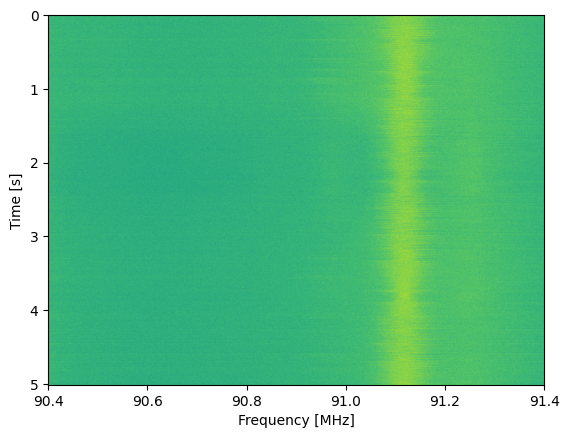

In [ ]:
# This code is modified from the pySDR guide. https://pysdr.org/index.html
# You may need to adjust code based on the parameters of your trace

samples = np.fromfile(filename, np.int8) #default setting for RF analyzer saves as 8-bit int. USRP uses np.complex64
samples = samples[::2] + 1j*samples[1::2] #for USRP comment this line out

num_rows = len(samples) // fft_size # // is an integer division which rounds down
spectrogram = np.zeros((num_rows, fft_size))
for i in range(num_rows):
    spectrogram[i,:] = 10*np.log10(np.abs(np.fft.fftshift(np.fft.fft(samples[i*fft_size:(i+1)*fft_size])))**2)
print(spectrogram)

plt.imshow(spectrogram, aspect='auto', extent = [center_frequency+sample_rate/-2/1e6, center_frequency+sample_rate/2/1e6, len(samples)/sample_rate, 0])
plt.xlabel("Frequency [MHz]")
plt.ylabel("Time [s]")
plt.show()
